# Intel Berkeley Research Lab Dataset - LSTM Autoencoder Testing
## Sensor Health Monitoring with Real-World IoT Data

---

### Dataset Overview
- **Source**: Intel Berkeley Research Lab
- **Sensors**: 54 sensor nodes deployed in the lab
- **Features**: Temperature, Humidity, Light, Voltage
- **Duration**: Feb 28 - Apr 5, 2004
- **Total Readings**: ~2.3M readings

### Our Approach
- Extract **temperature + humidity** readings (matching DHT11 sensor)
- Focus on a single sensor node with good data quality
- Train LSTM Autoencoder on first 70% (assumed healthy)
- Detect anomalies in last 30% using reconstruction error

---

## 1. Setup & Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import our existing modules
from iot_preprocessing import SensorPreprocessor, split_train_test_temporal
from iot_lstm_model import LSTMAutoencoder
from iot_health_score import SensorHealthMonitor

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Intel Berkeley Data Loader

### Data Format
```
timestamp   node_id  sensor_type  temperature  humidity  light  voltage
2004-02-28  1        1           19.9         37.0      45.08  2.69
```

### Strategy
- Parse space-delimited data
- Extract sensor nodes with both temperature AND humidity readings
- Select node with most complete data
- Create clean time-series with validation

In [7]:
# Column names based on dataset documentation
columns = ['date', 'time', 'epoch', 'node_id', 'temperature', 'humidity', 'light', 'voltage']
    
# Read data with chunking for memory efficiency
chunk_size = 100000
chunks = []
    
try:
    for i, chunk in enumerate(pd.read_csv(filepath, 
                                               sep='\s+',  # Space-delimited
                                               header=None,
                                               names=columns,
                                               chunksize=chunk_size,
                                               nrows=sample_limit)):
            chunks.append(chunk)
            if (i + 1) % 10 == 0:
                print(f"  Loaded {(i + 1) * chunk_size:,} rows...")
        
    df_raw = pd.concat(chunks, ignore_index=True)
    print(f"Loaded {len(df_raw):,} total readings")

except Exception as e:
        print(f"Error loading data: {e}")

Error loading data: name 'filepath' is not defined


In [11]:
df_raw['timestamp'] = pd.to_datetime(
        df_raw['date'] + ' ' + df_raw['time'], 
        format='mixed',  # Handle mixed datetime formats
        errors='coerce'  # Convert invalid dates to NaT
    )

NameError: name 'df_raw' is not defined

In [ ]:
# Remove rows with invalid timestamps
df_raw = df_raw.dropna(subset=['timestamp'])
# Analyze node data quality
print("\nSensor nodes")
node_stats = []

for node in df_raw['node_id'].unique():
        node_data = df_raw[df_raw['node_id'] == node]
        temp_valid = node_data['temperature'].notna().sum()
        hum_valid = node_data['humidity'].notna().sum()
        both_valid = ((node_data['temperature'].notna()) & (node_data['humidity'].notna())).sum()
        
        node_stats.append({
            'node_id': node,
            'total_readings': len(node_data),
            'temp_valid': temp_valid,
            'humidity_valid': hum_valid,
            'both_valid': both_valid,
            'completeness': both_valid / len(node_data) if len(node_data) > 0 else 0
        })
    
node_stats_df = pd.DataFrame(node_stats).sort_values('both_valid', ascending=False)
print(f"\nTop 5 nodes by data completeness:")
print(node_stats_df.head())

In [ ]:
    # Select target node
    if target_node_id is None:
        target_node_id = node_stats_df.iloc[0]['node_id']
        print(f"\n✓ Auto-selected Node {target_node_id} (best data quality)")
    else:
        print(f"\n✓ Using specified Node {target_node_id}")
    
    # Extract target node data
    df_node = df_raw[df_raw['node_id'] == target_node_id].copy()
    
    # Keep only timestamp, temperature, humidity
    df_clean = df_node[['timestamp', 'temperature', 'humidity']].copy()
    
    # Remove rows with missing values
    df_clean = df_clean.dropna()
    
    # Sort by timestamp
    df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)
    
    # Remove duplicates
    df_clean = df_clean.drop_duplicates(subset=['timestamp'], keep='first')
    
    # Summary statistics
    node_info = {
        'node_id': target_node_id,
        'total_samples': len(df_clean),
        'start_time': df_clean['timestamp'].min(),
        'end_time': df_clean['timestamp'].max(),
        'duration_days': (df_clean['timestamp'].max() - df_clean['timestamp'].min()).days,
        'temp_range': (df_clean['temperature'].min(), df_clean['temperature'].max()),
        'humidity_range': (df_clean['humidity'].min(), df_clean['humidity'].max()),
    }
    
    print(f"\n{'='*60}")
    print(f"EXTRACTED DATA SUMMARY - Node {target_node_id}")
    print(f"{'='*60}")
    print(f"Total samples: {node_info['total_samples']:,}")
    print(f"Time range: {node_info['start_time']} to {node_info['end_time']}")
    print(f"Duration: {node_info['duration_days']} days")
    print(f"Temperature range: {node_info['temp_range'][0]:.2f}°C to {node_info['temp_range'][1]:.2f}°C")
    print(f"Humidity range: {node_info['humidity_range'][0]:.2f}% to {node_info['humidity_range'][1]:.2f}%")
    print(f"{'='*60}\n")
    
    return df_clean, node_info


✓ Data loader function defined (FIXED VERSION)


## 3. Load and Explore Data

In [5]:
# Load Intel Berkeley data
# Note: Using sample_limit for initial testing. Set to None for full dataset
data_path = r'Intel Berkeley Research Lab Sensor Data\data.txt'

df, node_info = load_intel_berkeley_data(
    filepath=data_path,
    target_node_id=None,  # Auto-select best node
    sample_limit=500000   # Limit for memory efficiency (remove for full data)
)

# Display first few rows
print("\nFirst 10 readings:")
display(df.head(10))

print("\nBasic statistics:")
display(df.describe())

Loading Intel Berkeley dataset...
File: Intel Berkeley Research Lab Sensor Data\data.txt
✓ Loaded 500,000 total readings

Analyzing sensor nodes...

Top 5 nodes by data completeness:
   node_id  total_readings  temp_valid  humidity_valid  both_valid  \
6        7           55361       55361           55354       55354   
8        9           49890       49890           49888       49888   
9       10           47165       47165           47155       47155   
1        2           46915       46915           46915       46915   
2        3           46634       46634           46633       46633   

   completeness  
6      0.999874  
8      0.999960  
9      0.999788  
1      1.000000  
2      0.999979  

✓ Auto-selected Node 7.0 (best data quality)

EXTRACTED DATA SUMMARY - Node 7.0
Total samples: 55,354
Time range: 2004-02-28 01:05:16.649448 to 2004-04-01 23:48:49.729992
Duration: 33 days
Temperature range: 17.73°C to 122.15°C
Humidity range: -4.00% to 50.39%


First 10 readings:


,timestamp,temperature,humidity
0,2004-02-28 01:05:16.649448,19.4298,38.9401
1,2004-02-28 01:05:46.546353,19.4200,39.0763
2,2004-02-28 01:06:16.766558,19.4298,39.1443
3,2004-02-28 01:06:46.584280,19.4200,39.2123
4,2004-02-28 01:07:16.511303,19.4200,39.2803
5,2004-02-28 01:07:46.518010,19.4102,39.1443
6,2004-02-28 01:08:16.046134,19.4200,39.1443
7,2004-02-28 01:08:46.607604,19.4004,39.3483
8,2004-02-28 01:09:16.530298,19.4004,39.3483
9,2004-02-28 01:10:16.572357,19.3906,39.2463



Basic statistics:


,timestamp,temperature,humidity
count,55354,55354.000000,55354.000000
mean,2004-03-13 01:04:45.870187776,41.937863,32.130850
min,2004-02-28 01:05:16.649448,17.734400,-4.000000
25%,2004-03-04 18:53:39.457052288,20.782200,33.000900
50%,2004-03-11 18:22:21.424981504,22.105200,38.735700
75%,2004-03-19 14:22:39.190187776,25.535200,41.914700
max,2004-04-01 23:48:49.729992,122.153000,50.385800
std,NaN,39.674927,16.678133


## 4. Data Visualization

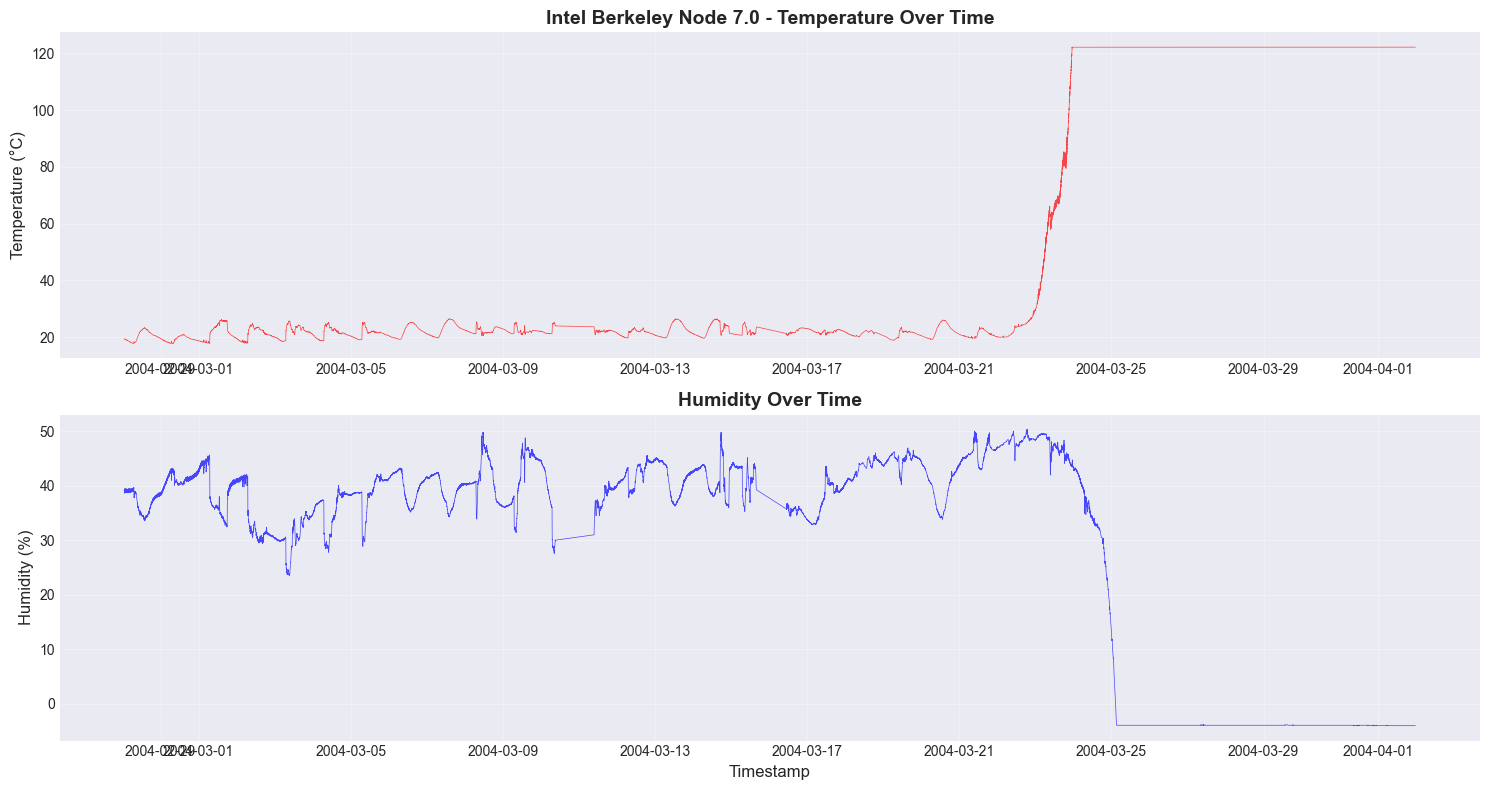

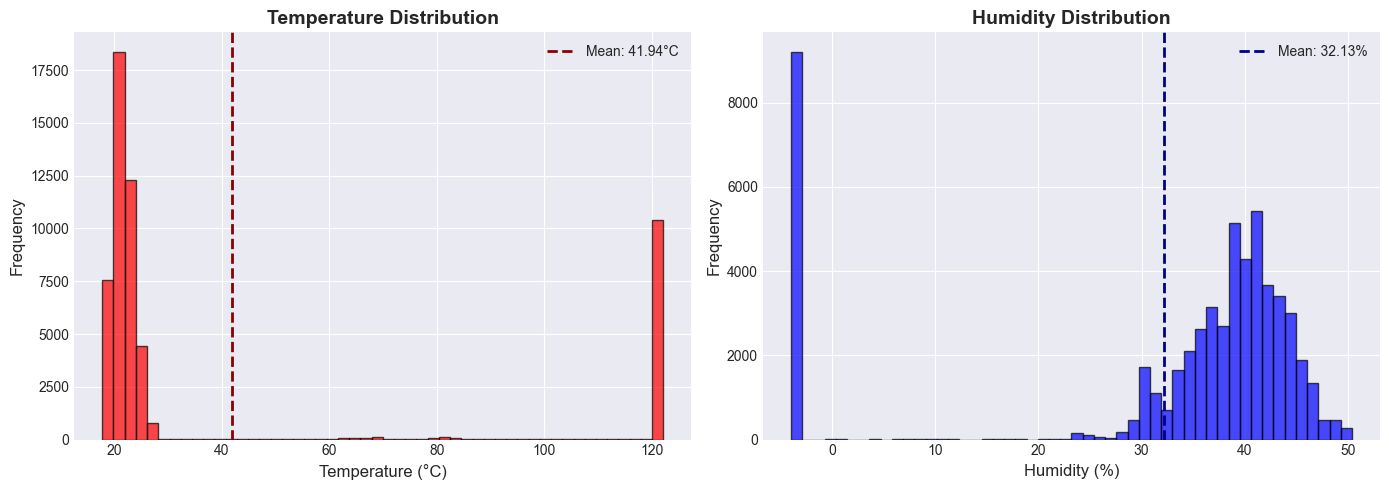

In [6]:
# Plot temperature and humidity over time
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Temperature plot
axes[0].plot(df['timestamp'], df['temperature'], alpha=0.7, linewidth=0.5, color='red')
axes[0].set_title(f"Intel Berkeley Node {node_info['node_id']} - Temperature Over Time", fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Humidity plot
axes[1].plot(df['timestamp'], df['humidity'], alpha=0.7, linewidth=0.5, color='blue')
axes[1].set_title('Humidity Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Timestamp', fontsize=12)
axes[1].set_ylabel('Humidity (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['temperature'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Temperature Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['temperature'].mean(), color='darkred', linestyle='--', linewidth=2, label=f"Mean: {df['temperature'].mean():.2f}°C")
axes[0].legend()

axes[1].hist(df['humidity'], bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Humidity Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Humidity (%)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(df['humidity'].mean(), color='darkblue', linestyle='--', linewidth=2, label=f"Mean: {df['humidity'].mean():.2f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

### Steps:
1. Temporal split (70% train, 30% test)
2. Outlier removal (IQR method)
3. Min-Max normalization
4. Sliding window creation (20 timesteps)

In [7]:
# Split data temporally
train_data, test_data = split_train_test_temporal(df, train_ratio=0.7)

print(f"Training data: {len(train_data):,} samples ({len(train_data)/len(df)*100:.1f}%)")
print(f"Testing data: {len(test_data):,} samples ({len(test_data)/len(df)*100:.1f}%)")
print(f"\nTraining period: {train_data['timestamp'].min()} to {train_data['timestamp'].max()}")
print(f"Testing period: {test_data['timestamp'].min()} to {test_data['timestamp'].max()}")


=== Temporal Split ===
Training period: 2004-02-28 01:05:16.649448 to 2004-03-17 12:49:13.022955
Testing period: 2004-03-17 12:49:46.635507 to 2004-04-01 23:48:49.729992
Train samples: 38747 (70%)
Test samples: 16607 (30%)
Training data: 38,747 samples (70.0%)
Testing data: 16,607 samples (30.0%)

Training period: 2004-02-28 01:05:16.649448 to 2004-03-17 12:49:13.022955
Testing period: 2004-03-17 12:49:46.635507 to 2004-04-01 23:48:49.729992


In [8]:
# Initialize preprocessor
preprocessor = SensorPreprocessor(window_size=20, stride=1)

# Prepare training data
print("Preprocessing training data...")
X_train, y_train = preprocessor.prepare_training_data(train_data)

# Prepare testing data
print("\nPreprocessing testing data...")
X_test, df_test_aligned = preprocessor.prepare_inference_data(test_data)

print(f"\n{'='*60}")
print("PREPROCESSING COMPLETE")
print(f"{'='*60}")
print(f"X_train shape: {X_train.shape}  (samples, window_size, features)")
print(f"X_test shape: {X_test.shape}")
print(f"Test data aligned: {len(df_test_aligned):,} rows")
print(f"{'='*60}\n")

Preprocessing training data...

=== Preparing Training Data ===
Removing statistical outliers from training data:
  humidity: removed 320 outliers (range: [27.21, 50.63])

Scaler fitted on 38427 samples
Temperature range: [17.73, 26.43]
Humidity range: [27.26, 49.87]
Created 38728 training windows
Input shape: (38728, 20, 2)

Preprocessing testing data...

=== Preparing Inference Data ===
Created 16588 inference windows
Input shape: (16588, 20, 2)
Aligned timestamps: 16588

PREPROCESSING COMPLETE
X_train shape: (38728, 20, 2)  (samples, window_size, features)
X_test shape: (16588, 20, 2)
Test data aligned: 16,588 rows



## 6. LSTM Autoencoder Training

### Model Architecture:
- Input: (batch, 20, 2) - 20 timesteps, 2 features (temp, humidity)
- Encoder: LSTM(64) → LSTM(32)
- Bottleneck: Dense(16)
- Decoder: LSTM(32) → LSTM(64) → Dense(2)
- Loss: MSE(input, output)

In [9]:
# Initialize model
model = LSTMAutoencoder(
    window_size=20,
    n_features=2,
    encoding_dim=16,
    lstm_units=(64, 32),
    dropout_rate=0.2
)

print("Model architecture created successfully")
print(f"Total parameters: {model.model.count_params():,}")


=== Model Architecture ===


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm1 (LSTM)            │ (None, 20, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm2 (LSTM)            │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 20, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm1 (LSTM)            │ (None, 20, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm2 (LSTM)            │ (None, 20, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 20, 2)          │           130 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,330 (239.57 KB)

 Trainable params: 61,330 (239.57 KB)

 Non-trainable params: 0 (0.00 B)

Model architecture created successfully
Total parameters: 61,330


In [10]:
# Train model
print("Starting model training...\n")

history = model.train(
    X_train=X_train,
    y_train=y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

print("\n✓ Training complete!")

Starting model training...


=== Training LSTM Autoencoder ===
Epoch 1/50
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - loss: 0.0241 - mae: 0.0963 - val_loss: 8.0066e-04 - val_mae: 0.0173 - learning_rate: 0.0010
Epoch 2/50
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - loss: 0.0025 - mae: 0.0382 - val_loss: 6.2255e-04 - val_mae: 0.0147 - learning_rate: 0.0010
Epoch 3/50
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step - loss: 0.0018 - mae: 0.0320 - val_loss: 5.4052e-04 - val_mae: 0.0133 - learning_rate: 0.0010
Epoch 4/50
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - loss: 0.0014 - mae: 0.0282 - val_loss: 6.0990e-04 - val_mae: 0.0149 - learning_rate: 0.0010
Epoch 5/50
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - loss: 0.0012 - mae: 0.0255 - val_loss: 7.5257e-04 - val_mae: 0.0183 - learning_rate: 0.0010
Epoch 6/50
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - loss: 0.0011 - mae: 0.0238 - val_loss: 6.4970e-04 - val_mae: 0.0156 - learning_rate: 0.0010
Epoch 7/50
1089/1090 ━━━━━━━━━━━━━━━━

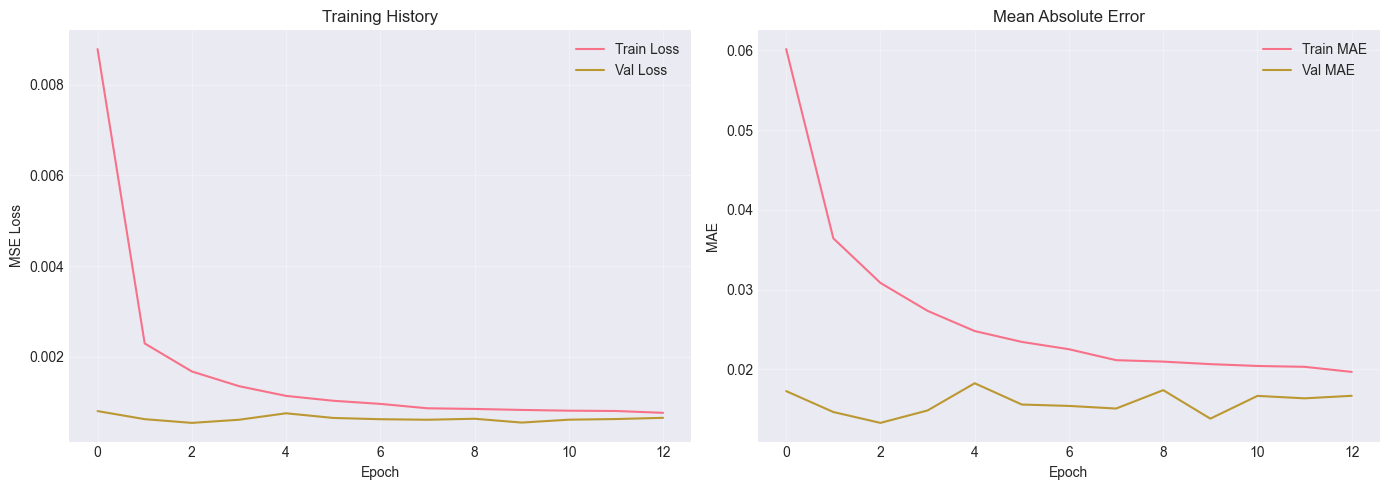

In [11]:
# Plot training history
model.plot_training_history(figsize=(14, 5))
plt.show()

## 7. Set Anomaly Threshold

In [12]:
# Calculate threshold from training data
threshold = model.set_threshold(
    X_train=X_train,
    method='percentile',
    percentile=95
)

print(f"Anomaly detection threshold: {threshold:.6f}")
print(f"\nInterpretation:")
print(f"  - Reconstruction error > {threshold:.6f} → Anomaly")
print(f"  - Threshold set at 95th percentile of training errors")
print(f"  - Expected false positive rate: ~5%")


Threshold set at 95th percentile: 0.001110
  False positive rate on training: 5.00%
Anomaly detection threshold: 0.001110

Interpretation:
  - Reconstruction error > 0.001110 → Anomaly
  - Threshold set at 95th percentile of training errors
  - Expected false positive rate: ~5%


## 8. Anomaly Detection on Test Data

In [13]:
# Detect anomalies on test data
test_errors, is_anomaly = model.detect_anomalies(X_test)

print(f"Test set anomaly detection results:")
print(f"  Total test samples: {len(test_errors):,}")
print(f"  Anomalies detected: {is_anomaly.sum():,} ({is_anomaly.sum()/len(is_anomaly)*100:.2f}%)")
print(f"  Normal samples: {(~is_anomaly).sum():,} ({(~is_anomaly).sum()/len(is_anomaly)*100:.2f}%)")
print(f"\nReconstruction error statistics:")
print(f"  Mean: {test_errors.mean():.6f}")
print(f"  Std: {test_errors.std():.6f}")
print(f"  Min: {test_errors.min():.6f}")
print(f"  Max: {test_errors.max():.6f}")
print(f"  Median: {np.median(test_errors):.6f}")

Test set anomaly detection results:
  Total test samples: 16,588
  Anomalies detected: 12,349 (74.45%)
  Normal samples: 4,239 (25.55%)

Reconstruction error statistics:
  Mean: 40.559082
  Std: 28.718172
  Min: 0.000011
  Max: 62.403012
  Median: 62.396298


## 9. Health Score Calculation

In [14]:
# Initialize health monitor
health_monitor = SensorHealthMonitor(
    ema_alpha=0.05,
    drift_window=50,
    noise_window=20,
    freeze_threshold=5
)

# Process test data batch
df_results = health_monitor.process_batch(
    df=df_test_aligned,
    anomaly_scores=test_errors,
    threshold=threshold
)

print("✓ Health scores calculated")
print(f"\nResults DataFrame shape: {df_results.shape}")
print(f"Columns: {list(df_results.columns)}")

# Display sample results
print("\nSample results:")
display(df_results[['timestamp', 'temperature', 'humidity', 'anomaly_score', 'health_score', 'fault_type', 'alert_level']].head(10))

✓ Health scores calculated

Results DataFrame shape: (16588, 7)
Columns: ['timestamp', 'temperature', 'humidity', 'health_score', 'anomaly_score', 'fault_type', 'alert_level']

Sample results:


,timestamp,temperature,humidity,anomaly_score,health_score,fault_type,alert_level
0,2004-03-17 13:02:14.823239,21.7524,40.4328,0.000121,96.285271,Healthy,Normal
1,2004-03-17 13:02:45.741164,21.7524,40.4666,0.000119,96.287861,Communication Failure,Critical
2,2004-03-17 13:03:57.693614,21.7720,40.3990,0.000119,96.290525,Communication Failure,Critical
3,2004-03-17 13:04:20.054412,21.7720,40.3652,0.000118,96.295118,Communication Failure,Critical
4,2004-03-17 13:04:53.375605,21.7916,40.3652,0.000119,96.298091,Communication Failure,Critical
5,2004-03-17 13:05:13.074543,21.7720,40.3652,0.000118,96.301905,Communication Failure,Critical
6,2004-03-17 13:05:43.122100,21.7916,40.3652,0.000117,96.307108,Communication Failure,Critical
7,2004-03-17 13:06:45.072686,21.7916,40.3314,0.000117,96.311959,Communication Failure,Critical
8,2004-03-17 13:07:34.771841,21.7916,40.3314,0.000117,96.316595,Communication Failure,Critical
9,2004-03-17 13:07:45.850769,21.8014,40.3314,0.000116,96.322759,Communication Failure,Critical


## 10. Visualization & Analysis

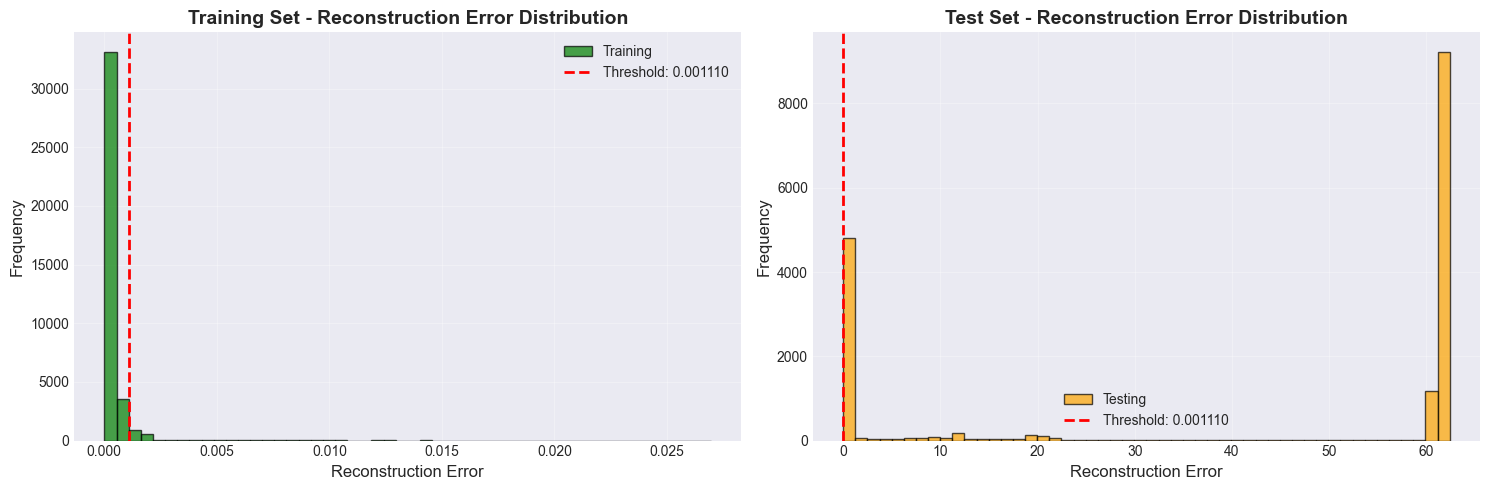

In [15]:
# Reconstruction error distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training errors
train_errors = model.compute_reconstruction_error(X_train)
axes[0].hist(train_errors, bins=50, color='green', alpha=0.7, edgecolor='black', label='Training')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')
axes[0].set_title('Training Set - Reconstruction Error Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Reconstruction Error', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test errors
axes[1].hist(test_errors, bins=50, color='orange', alpha=0.7, edgecolor='black', label='Testing')
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')
axes[1].set_title('Test Set - Reconstruction Error Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Reconstruction Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

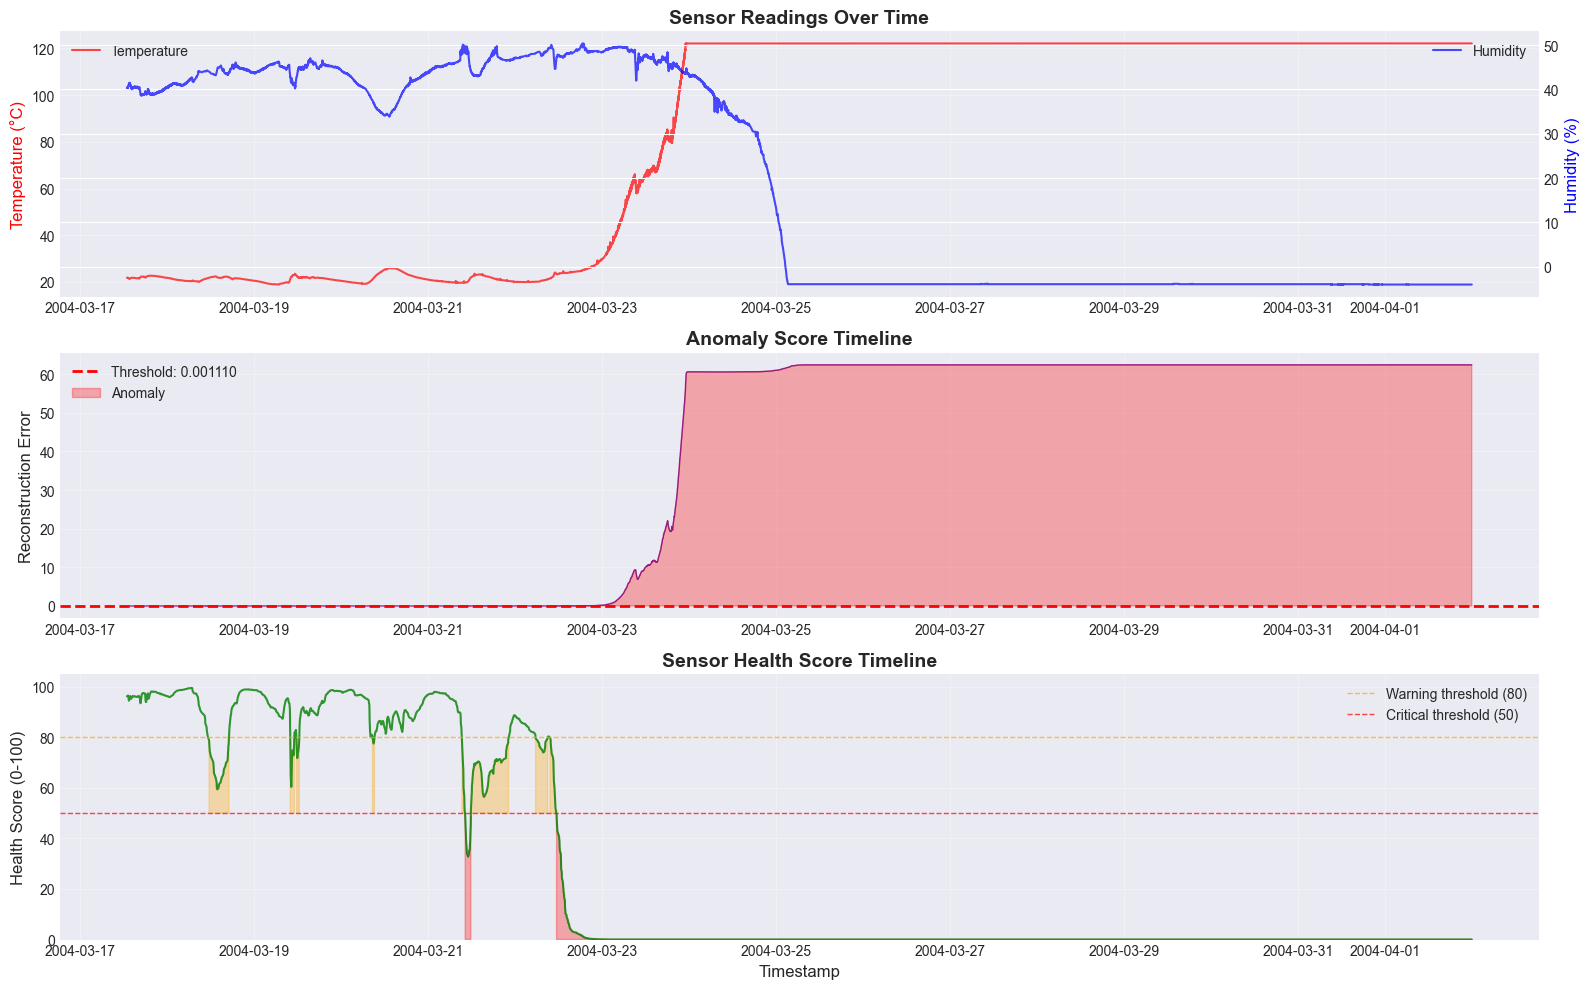

In [16]:
# Anomaly detection timeline
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Temperature and humidity
axes[0].plot(df_results['timestamp'], df_results['temperature'], alpha=0.7, label='Temperature', color='red')
ax0_twin = axes[0].twinx()
ax0_twin.plot(df_results['timestamp'], df_results['humidity'], alpha=0.7, label='Humidity', color='blue')
axes[0].set_ylabel('Temperature (°C)', fontsize=12, color='red')
ax0_twin.set_ylabel('Humidity (%)', fontsize=12, color='blue')
axes[0].set_title('Sensor Readings Over Time', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')
ax0_twin.legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Reconstruction error
axes[1].plot(df_results['timestamp'], df_results['anomaly_score'], alpha=0.8, linewidth=1, color='purple')
axes[1].axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')
axes[1].fill_between(df_results['timestamp'], 0, df_results['anomaly_score'], 
                      where=(df_results['anomaly_score'] > threshold), 
                      alpha=0.3, color='red', label='Anomaly')
axes[1].set_ylabel('Reconstruction Error', fontsize=12)
axes[1].set_title('Anomaly Score Timeline', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Health score
axes[2].plot(df_results['timestamp'], df_results['health_score'], alpha=0.8, linewidth=1.5, color='green')
axes[2].axhline(80, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Warning threshold (80)')
axes[2].axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Critical threshold (50)')
axes[2].fill_between(df_results['timestamp'], 0, df_results['health_score'],
                      where=(df_results['health_score'] < 50),
                      alpha=0.3, color='red')
axes[2].fill_between(df_results['timestamp'], 50, df_results['health_score'],
                      where=((df_results['health_score'] >= 50) & (df_results['health_score'] < 80)),
                      alpha=0.3, color='orange')
axes[2].set_ylabel('Health Score (0-100)', fontsize=12)
axes[2].set_xlabel('Timestamp', fontsize=12)
axes[2].set_title('Sensor Health Score Timeline', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 105])

plt.tight_layout()
plt.show()

## 11. Fault Type Analysis

Fault Type Distribution:
Communication Failure: 16,587 samples (99.99%)
Healthy             :      1 samples ( 0.01%)


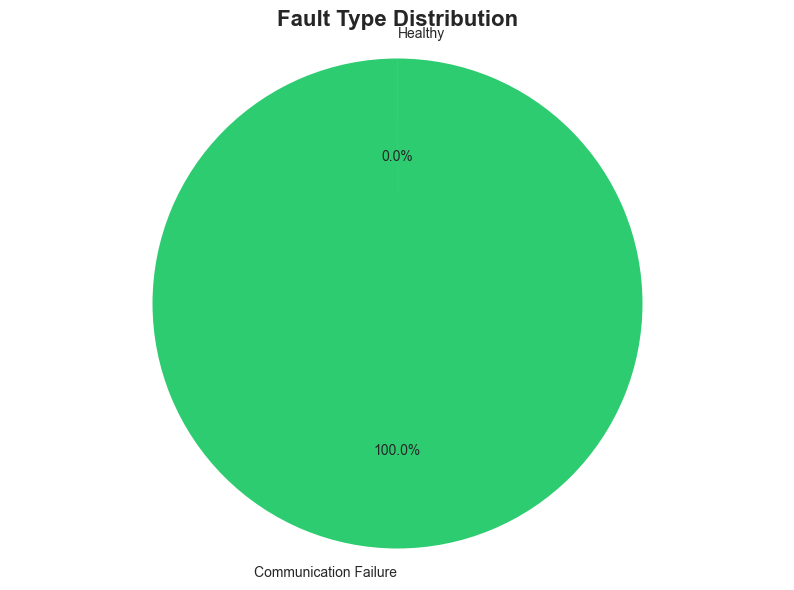

In [18]:
# Fault type distribution
fault_counts = df_results['fault_type'].value_counts()

print("Fault Type Distribution:")
print("="*60)
for fault, count in fault_counts.items():
    percentage = (count / len(df_results)) * 100
    # fault is already a string, no need for .value
    fault_name = fault.value if hasattr(fault, 'value') else fault
    print(f"{fault_name:20s}: {count:6,} samples ({percentage:5.2f}%)")
print("="*60)

# Pie chart
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#95a5a6']
# Handle both enum and string cases for labels
labels = [f.value if hasattr(f, 'value') else f for f in fault_counts.index]
ax.pie(fault_counts.values, labels=labels, 
       autopct='%1.1f%%', startangle=90, colors=colors[:len(fault_counts)])
ax.set_title('Fault Type Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()


Alert Level Distribution:
Critical       : 16,587 samples (99.99%)
Normal         :      1 samples ( 0.01%)


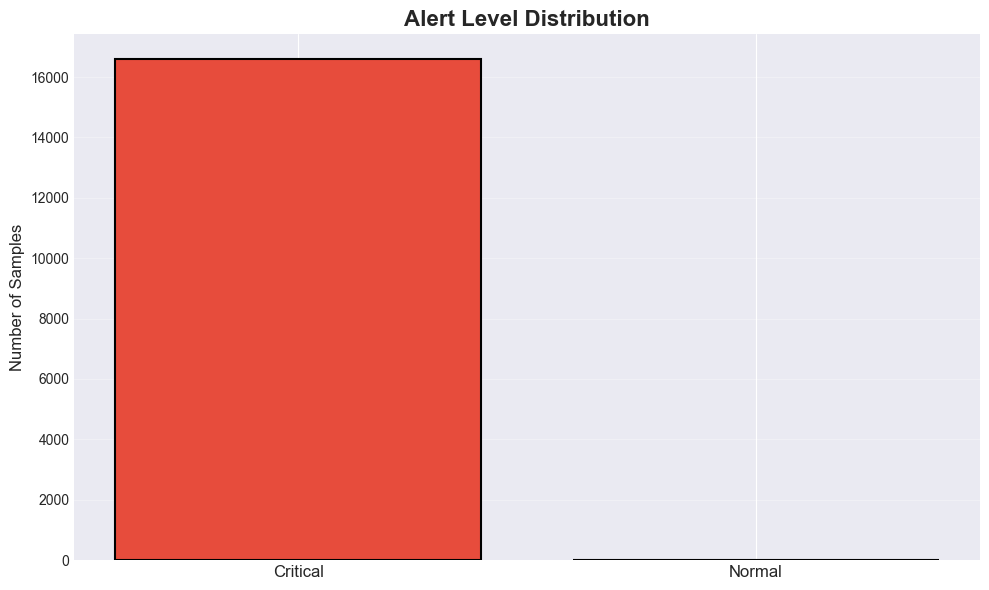

In [19]:
# Alert level distribution
alert_counts = df_results['alert_level'].value_counts()

print("\nAlert Level Distribution:")
print("="*60)
for alert, count in alert_counts.items():
    percentage = (count / len(df_results)) * 100
    # alert is already a string, no need for .value
    alert_name = alert.value if hasattr(alert, 'value') else alert
    print(f"{alert_name:15s}: {count:6,} samples ({percentage:5.2f}%)")
print("="*60)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
alert_colors = {'Normal': '#2ecc71', 'Warning': '#f39c12', 'Critical': '#e74c3c'}
# Handle both enum and string cases
labels = [a.value if hasattr(a, 'value') else a for a in alert_counts.index]
colors_list = [alert_colors.get(label, '#95a5a6') for label in labels]
ax.bar(range(len(alert_counts)), alert_counts.values, color=colors_list, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(alert_counts)))
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Alert Level Distribution', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 12. Performance Metrics

In [20]:
# Generate comprehensive report
health_monitor.generate_report(df_results)

{'current_health': 5.299354303121801e-267,
 'current_fault': 'Communication Failure',
 'current_alert': 'Critical',
 'uptime_percent': 0.006028454304316373,
 'fault_counts': {'Communication Failure': 16587, 'Healthy': 1},
 'total_readings': 16588,
 'recommendation': '🔴 CRITICAL: Check sensor wiring and power supply immediately'}

In [22]:
# Summary statistics
print("\n" + "="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
print(f"Dataset: Intel Berkeley Research Lab - Node {node_info['node_id']}")
print(f"Total samples processed: {len(df_results):,}")
print(f"\nHealth Score Statistics:")
print(f"  Mean health: {df_results['health_score'].mean():.2f}/100")
print(f"  Median health: {df_results['health_score'].median():.2f}/100")
print(f"  Min health: {df_results['health_score'].min():.2f}/100")
print(f"  Max health: {df_results['health_score'].max():.2f}/100")
print(f"\nAnomaly Detection:")
print(f"  Anomaly rate: {is_anomaly.sum()/len(is_anomaly)*100:.2f}%")
print(f"  Normal rate: {(~is_anomaly).sum()/len(is_anomaly)*100:.2f}%")
print(f"\nSystem Uptime:")
# FIXED: alert_level values are already strings, no need for .value
normal_count = (df_results['alert_level'] == 'Normal').sum()
uptime = (normal_count / len(df_results)) * 100
print(f"  Uptime (Normal status): {uptime:.2f}%")
print(f"  Downtime (Warning/Critical): {100-uptime:.2f}%")
print("="*70)


FINAL PERFORMANCE SUMMARY
Dataset: Intel Berkeley Research Lab - Node 7.0
Total samples processed: 16,588

Health Score Statistics:
  Mean health: 25.14/100
  Median health: 0.00/100
  Min health: 0.00/100
  Max health: 99.57/100

Anomaly Detection:
  Anomaly rate: 74.45%
  Normal rate: 25.55%

System Uptime:
  Uptime (Normal status): 0.01%
  Downtime (Warning/Critical): 99.99%


## 13. Save Model & Results

In [23]:
import os

# Create output directory
output_dir = 'intel_berkeley_results'
os.makedirs(output_dir, exist_ok=True)

# Save model
model.save(os.path.join(output_dir, 'lstm_autoencoder_intel.h5'))
print(f"✓ Model saved to {output_dir}/lstm_autoencoder_intel.h5")

# Save preprocessor
preprocessor.save(os.path.join(output_dir, 'preprocessor_intel.pkl'))
print(f"✓ Preprocessor saved to {output_dir}/preprocessor_intel.pkl")

# Save results
df_results.to_csv(os.path.join(output_dir, 'detection_results_intel.csv'), index=False)
print(f"✓ Results saved to {output_dir}/detection_results_intel.csv")

# Save threshold
np.save(os.path.join(output_dir, 'threshold_intel.npy'), threshold)
print(f"✓ Threshold saved to {output_dir}/threshold_intel.npy")

print(f"\n✓ All artifacts saved to '{output_dir}/' directory")

Model saved to intel_berkeley_results\lstm_autoencoder_intel.h5
✓ Model saved to intel_berkeley_results/lstm_autoencoder_intel.h5
Preprocessor saved to intel_berkeley_results\preprocessor_intel.pkl
✓ Preprocessor saved to intel_berkeley_results/preprocessor_intel.pkl
✓ Results saved to intel_berkeley_results/detection_results_intel.csv
✓ Threshold saved to intel_berkeley_results/threshold_intel.npy

✓ All artifacts saved to 'intel_berkeley_results/' directory
